# Simulacio 1 Termodinàmica estadística

## Seccio 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
#kB = 1.38 * 10**(-23) # podem treballar en unitats on k_B = 1
epsilon = 1.0  # energia base
kB = 1.0

# Nivells d'energia
levels = np.array([0.0, epsilon, 10 * epsilon])
n_levels = len(levels)
#print(n_levels)

In [2]:
def initialize_system(N):
    """
    Inicialitza el sistema amb N partícules distribuïdes
    aleatòriament amb probabilitat 1/3 en cada nivell.
    """
    return np.random.choice(n_levels, size=N)

#plt.hist(initialize_system(1000))
#plt.show()

In [3]:
def total_energy(state):
    """
    Calcula l'energia total del sistema donat l'estat actual.
    """
    return np.sum(levels[state])

In [4]:
def metropolis_step(state, T):
    """
    Realitza un pas de Metropolis:
    - escull una partícula a l'atzar
    - proposa un canvi de nivell
    - accepta o rebutja segons criteri de Metropolis
    """
    beta = 1.0 / (kB * T)
    
    # escollim una partícula
    i = np.random.randint(len(state))
    
    old_level = state[i]
    
    # proposem un nou nivell diferent
    new_level = np.random.choice([l for l in range(n_levels) if l != old_level])
    
    dE = levels[new_level] - levels[old_level]
    
    # criteri de Metropolis MIRAR WIKIPEDIA!!!
    if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
        state[i] = new_level

In [5]:
def run_simulation(N, T, n_steps, burn_in):
    """
    Executa la simulació de Metropolis i retorna:
    - ocupacions mitjanes
    - energia mitjana
    - energies (per fluctuacions)
    """
    state = initialize_system(N)
    
    energies = []
    occupations = []
    
    for step in range(n_steps):
        metropolis_step(state, T)
        energies.append(total_energy(state))
        counts = np.bincount(state, minlength=n_levels)
        occupations.append(counts / N)
    return (
        occupations,
        np.mean(occupations[burn_in:], axis=0),
        np.mean(energies[burn_in:]),
        np.array(energies[burn_in:])
    )

In [6]:
N = 1000
temperatures = np.linspace(0.5, 10, 100) # 100 simulacions
n_steps = 6000
burn_in = 2000

occ_results = []

for T in temperatures:
    _, occ, E_mean, _ = run_simulation(N, T, n_steps, burn_in)
    occ_results.append(occ)

occ_results = np.array(occ_results)

#print(occ_results)
#print(E_mean)

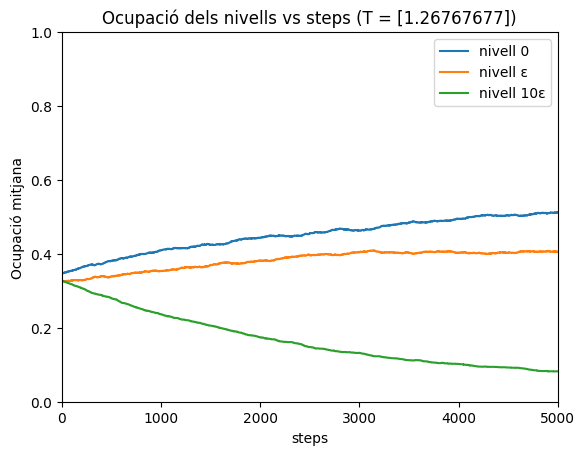

In [19]:
t_random = np.random.choice(temperatures, size = 1)
#t_random = 3
occ_list, occ, E_mean, _ = run_simulation(N, T, n_steps, burn_in)
#print(occ_list)
occ_list = np.array(occ_list)

plt.plot(occ_list[:,0], label="nivell 0")
plt.plot(occ_list[:,1], label="nivell ε")
plt.plot(occ_list[:,2], label="nivell 10ε")

plt.xlabel("steps")
plt.ylabel("Ocupació mitjana")
plt.legend()
plt.title(f"Ocupació dels nivells vs steps (T = {t_random})")
plt.ylim(0, 1)
plt.xlim(0, 5000)

plt.show()

Explicar lo del burn_in= 2000

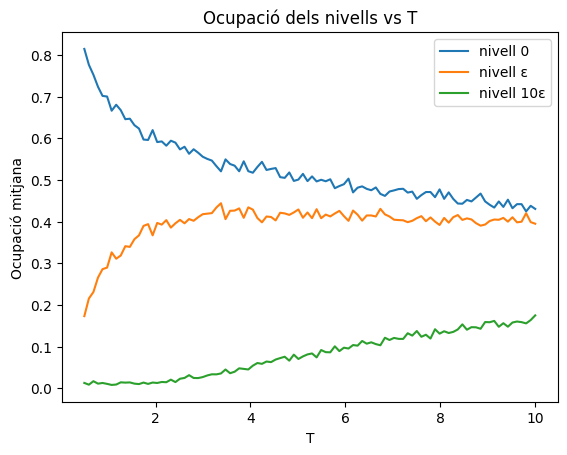

In [8]:
plt.figure()

plt.plot(temperatures, occ_results[:,0], label="nivell 0")
plt.plot(temperatures, occ_results[:,1], label="nivell ε")
plt.plot(temperatures, occ_results[:,2], label="nivell 10ε")

plt.xlabel("T")
plt.ylabel("Ocupació mitjana")
plt.legend()
plt.title("Ocupació dels nivells vs T")

plt.show()

In [9]:
def theoretical_occupation(T):
    beta = 1.0 / (kB * T)
    weights = np.exp(-beta * levels)
    Z = np.sum(weights)
    return weights / Z

theory = np.array([theoretical_occupation(T) for T in temperatures])

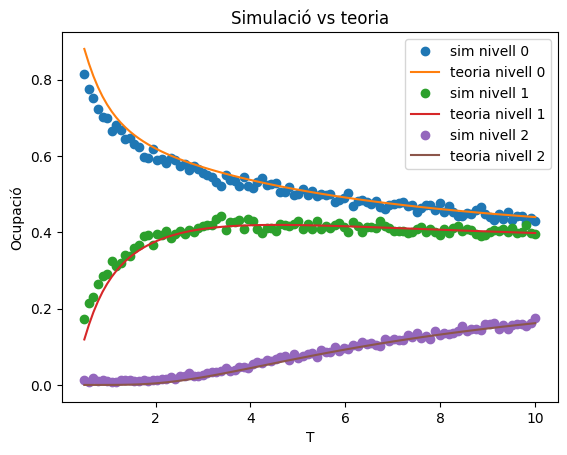

In [10]:
plt.figure()

for i in range(n_levels):
    plt.plot(temperatures, occ_results[:,i], 'o', label=f"sim nivell {i}")
    plt.plot(temperatures, theory[:,i], '-', label=f"teoria nivell {i}")

plt.xlabel("T")
plt.ylabel("Ocupació")
plt.legend()
plt.title("Simulació vs teoria")

plt.show()

In [11]:
def energy_fluctuations(energies):
    """
    Calcula <E^2> - <E>^2
    """
    return np.mean(energies**2) - np.mean(energies)**2

In [12]:
Ns = [100, 300, 1000, 3000]
T = 3.0
n_steps=6000
burn_in = 2000

flucts = []

for N in Ns:
    _, _, _, energies = run_simulation(N, T, n_steps, burn_in)
    flucts.append(energy_fluctuations(energies))

flucts = np.array(flucts)

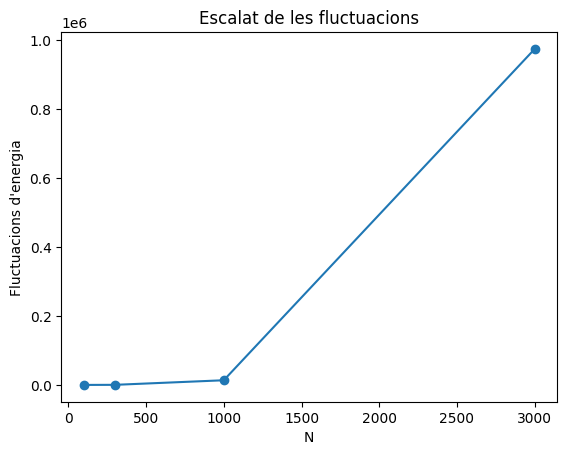

In [13]:
plt.figure()

plt.plot(Ns, flucts, 'o-')

plt.xlabel("N")
plt.ylabel("Fluctuacions d'energia")
plt.title("Escalat de les fluctuacions")

plt.show()